
# 🏠 Short-Term Rental Investment Analysis
### 1525 N Hayworth Ave #302, Los Angeles, CA 90046 (West Hollywood submarket)

**Prepared as:** Data Analyst / Data Scientist / BI Consultant deliverable

This notebook performs an end-to-end quantitative analysis of the subject property's short-term
rental (STR / Airbnb) investment potential, using four data sources:

| # | File | Contents |
|---|------|----------|
| 1 | `Property_and_Comps_Snapshot.csv` | MLS listing detail for the subject property |
| 2 | `List_Comps_API_Response.json` | 20 nearby active Airbnb comparable listings (Mashvisor) |
| 3 | `Address_Lookup_API_Response.json` | Mashvisor market-level rental performance summary for the address |
| 4 | `STR_Monthly_Performance_ZIP.csv` | Rolling 30-day STR performance for 445 ZIP codes (Bay Area + LA metro) |

**Analytical techniques applied:**
- Data cleaning & feature engineering
- Exploratory Data Analysis (EDA) & correlation analysis
- **K-Means clustering** — segmenting comps and ZIP codes into performance tiers
- **DBSCAN** — density-based clustering / outlier & anomaly detection (feature space + geospatial)
- **Linear Regression** — revenue driver modeling
- **Logistic Regression & Perceptron** — binary classification of "high performer" listings
- **Neural Network (MLP)** — non-linear regression & classification benchmark
- Model comparison, diagnostics, and business recommendations

---


In [ ]:

# ------------------------------------------------------------------
# 0. Environment setup
# ------------------------------------------------------------------
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression, Perceptron
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve, roc_auc_score,
                              silhouette_score)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 42
DATA_DIR = "data"
print("Environment ready.")


Environment ready.



## 1. Data Loading

We load all four sources. The two JSON files are Mashvisor API responses that begin with
`//` comment lines documenting the request — these are stripped before parsing.


In [ ]:

def load_commented_json(path):
    # Load a JSON file that may have // comment lines before the JSON body.
    with open(path, 'r') as f:
        lines = f.readlines()
    json_text = ''.join(l for l in lines if not l.strip().startswith('//'))
    return json.loads(json_text)

# --- 1. Subject property + comps snapshot (MLS) ---
df_property = pd.read_csv(f"{DATA_DIR}/Property_and_Comps_Snapshot.csv", encoding='utf-8-sig')

# --- 2. Active Airbnb comps near the subject property ---
list_comps_raw = load_commented_json(f"{DATA_DIR}/List_Comps_API_Response.json")
df_comps = pd.DataFrame(list_comps_raw['content']['list'])

# --- 3. Address-level market summary ---
addr_lookup = load_commented_json(f"{DATA_DIR}/Address_Lookup_API_Response.json")
market_summary = addr_lookup['content']

# --- 4. ZIP-code level STR performance (445 ZIP codes) ---
df_zip = pd.read_csv(f"{DATA_DIR}/STR_Monthly_Performance_ZIP.csv")

print(f"Subject property rows      : {df_property.shape}")
print(f"Airbnb comps                : {df_comps.shape}")
print(f"ZIP-level STR performance   : {df_zip.shape}")
print(f"Market summary keys         : {list(market_summary.keys())[:8]} ...")


Subject property rows      : (1, 89)
Airbnb comps                : (20, 45)
ZIP-level STR performance   : (445, 23)
Market summary keys         : ['median_home_value', 'sample_size', 'median_occupancy_rate', 'median_rental_income', 'median_night_rate', 'median_guests_capacity', 'median_annual_revenue', 'median_annual_expenses'] ...


In [ ]:

df_property[['address','city','state','zip','beds','baths','sqft','year_built',
             'list_price','last_sale_price','list_price','days_on_market','latitude','longitude']].T


,0
address,1525 N Hayworth Ave #302
city,Los Angeles
state,CA
zip,90046
beds,3
baths,2
sqft,2140
year_built,1959
list_price,1050000
last_sale_price,520000



## 2. Data Cleaning & Feature Engineering

Key derived features for the Airbnb comps:
- `revenue_per_bed`, `price_per_guest` — normalized economics
- `occupancy` already 0–100 scale → convert to fraction
- `is_entire_home` — flag from `room_type_category`
- `distance` (miles from subject property, provided by API)

For the ZIP-level file we build **blended (all-bedroom-count) ADR/occupancy/revenue** plus
a **bedroom-mix revenue premium** to see how 3-bed units (matching the subject property) compare
to the ZIP blended average.


In [ ]:

# ---- Clean comps ----
comp_cols = ['id','name','address','airbnb_city','zip','property_type','room_type',
             'room_type_category','capacity_of_people','num_of_beds','num_of_baths',
             'night_price','cleaning_fee_native','occupancy','nights_booked','rental_income',
             'reviews_count','star_rating','lat','lon','distance']
df_comps_clean = df_comps[comp_cols].copy()

df_comps_clean['occupancy_frac'] = df_comps_clean['occupancy'] / 100
df_comps_clean['is_entire_home'] = (df_comps_clean['room_type_category'] == 'entire_home').astype(int)
df_comps_clean['revenue_per_bed'] = df_comps_clean['rental_income'] / df_comps_clean['num_of_beds'].replace(0, np.nan)
df_comps_clean['price_per_guest'] = df_comps_clean['night_price'] / df_comps_clean['capacity_of_people'].replace(0, np.nan)
df_comps_clean['star_rating'] = df_comps_clean['star_rating'].fillna(df_comps_clean['star_rating'].median())
df_comps_clean['reviews_count'] = df_comps_clean['reviews_count'].fillna(0)

print(f"Cleaned comps: {df_comps_clean.shape[0]} listings, {df_comps_clean.shape[1]} features")
df_comps_clean.describe().T.round(2)


Cleaned comps: 20 listings, 25 features


,count,mean,std,min,25%,50%,75%,max
id,20.0,1.020491e+08,135.24,1.020489e+08,1.020490e+08,1.020491e+08,1.020492e+08,1.020493e+08
capacity_of_people,20.0,3.700000e+00,1.84,2.000000e+00,2.750000e+00,3.500000e+00,4.000000e+00,1.000000e+01
num_of_beds,20.0,1.700000e+00,1.17,0.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,5.000000e+00
num_of_baths,20.0,1.320000e+00,0.73,1.000000e+00,1.000000e+00,1.000000e+00,1.120000e+00,4.000000e+00
night_price,20.0,2.348500e+02,150.39,1.260000e+02,1.577500e+02,1.815000e+02,2.245000e+02,7.730000e+02
cleaning_fee_native,20.0,1.361000e+02,65.49,7.000000e+01,9.000000e+01,1.200000e+02,1.562500e+02,3.000000e+02
occupancy,20.0,5.045000e+01,15.82,1.600000e+01,4.350000e+01,4.950000e+01,6.200000e+01,8.200000e+01
nights_booked,20.0,1.434000e+02,40.69,4.900000e+01,1.085000e+02,1.485000e+02,1.697500e+02,2.280000e+02
rental_income,20.0,3.544150e+03,2338.50,9.750000e+02,2.099000e+03,3.104000e+03,4.128750e+03,1.176700e+04
reviews_count,20.0,4.350000e+00,0.88,3.000000e+00,4.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00


In [ ]:

# ---- Clean ZIP-level performance file ----
df_zip_clean = df_zip.copy()
num_cols = df_zip_clean.columns.drop(['zip_code','data_granularity','metric_window','currency'])
df_zip_clean[num_cols] = df_zip_clean[num_cols].apply(pd.to_numeric, errors='coerce')

# Drop ZIPs with no usable blended revenue signal
df_zip_clean = df_zip_clean.dropna(subset=['estimated_monthly_revenue_usd','occupancy_rate_pct','average_daily_rate_usd'])

# 3-bed premium vs blended average (subject property is a 3BR condo)
df_zip_clean['three_bed_vs_blended_revenue_pct'] = (
    (df_zip_clean['three_bed_estimated_monthly_revenue_usd'] - df_zip_clean['estimated_monthly_revenue_usd'])
    / df_zip_clean['estimated_monthly_revenue_usd'] * 100
)
df_zip_clean['revpar'] = df_zip_clean['average_daily_rate_usd'] * df_zip_clean['occupancy_rate_pct'] / 100

print(f"Cleaned ZIP data: {df_zip_clean.shape[0]} ZIP codes retained (of {df_zip.shape[0]})")
df_zip_clean[['active_listings','estimated_monthly_revenue_usd','occupancy_rate_pct',
              'average_daily_rate_usd','three_bed_estimated_monthly_revenue_usd','revpar']].describe().round(1)


Cleaned ZIP data: 445 ZIP codes retained (of 445)


,active_listings,estimated_monthly_revenue_usd,occupancy_rate_pct,average_daily_rate_usd,three_bed_estimated_monthly_revenue_usd,revpar
count,445.0,445.0,445.0,445.0,437.0,445.0
mean,343.0,1446.6,24.3,241.3,1726.5,54.8
std,316.0,595.3,9.5,93.1,1074.7,20.6
min,102.0,0.0,3.0,80.0,-224.8,16.8
25%,149.0,1040.0,18.0,175.0,1040.2,40.3
50%,224.0,1358.4,23.0,213.0,1538.5,51.7
75%,424.0,1739.8,29.0,292.0,2130.4,66.8
max,2402.0,4001.6,78.0,695.0,7860.9,149.5



## 3. Exploratory Data Analysis

### 3.1 Subject property vs. the comp set


In [ ]:

subject = df_property.iloc[0]
print("SUBJECT PROPERTY")
print("-"*50)
print(f"Address        : {subject['address']}, {subject['city']} {subject['zip']}")
print(f"Beds / Baths    : {subject['beds']} / {subject['baths']}")
print(f"Sqft            : {subject['sqft']:,}")
print(f"List price      : ${subject['list_price']:,}")
print(f"$/sqft (list)   : ${subject['list_price']/subject['sqft']:,.0f}")
print(f"Last sale price : ${subject['last_sale_price']:,}  ({subject['last_sale_date']})")
print(f"Days on market  : {subject['days_on_market']}")
print()
print("MARKET SUMMARY (Mashvisor address lookup, West Hollywood, n={})".format(market_summary['sample_size']))
print("-"*50)
for k in ['median_home_value','median_night_rate','median_occupancy_rate','median_annual_revenue',
          'median_annual_expenses','annual_cash_flow','cap_rate','cash_on_cash','price_to_rent_ratio']:
    v = market_summary[k]
    print(f"{k:28s}: {v:,.2f}" if isinstance(v,(int,float)) else f"{k:28s}: {v}")


SUBJECT PROPERTY
--------------------------------------------------
Address        : 1525 N Hayworth Ave #302, Los Angeles 90046
Beds / Baths    : 3 / 2
Sqft            : 2,140
List price      : $1,050,000
$/sqft (list)   : $491
Last sale price : $520,000  (2/17/22 8:00)
Days on market  : 6

MARKET SUMMARY (Mashvisor address lookup, West Hollywood, n=1)
--------------------------------------------------
median_home_value           : 2,297,000.00
median_night_rate           : 336.00
median_occupancy_rate       : 55.00
median_annual_revenue       : 67,812.00
median_annual_expenses      : 59,919.00
annual_cash_flow            : 5,509.44
cap_rate                    : 0.24
cash_on_cash                : 0.24
price_to_rent_ratio         : 35.11


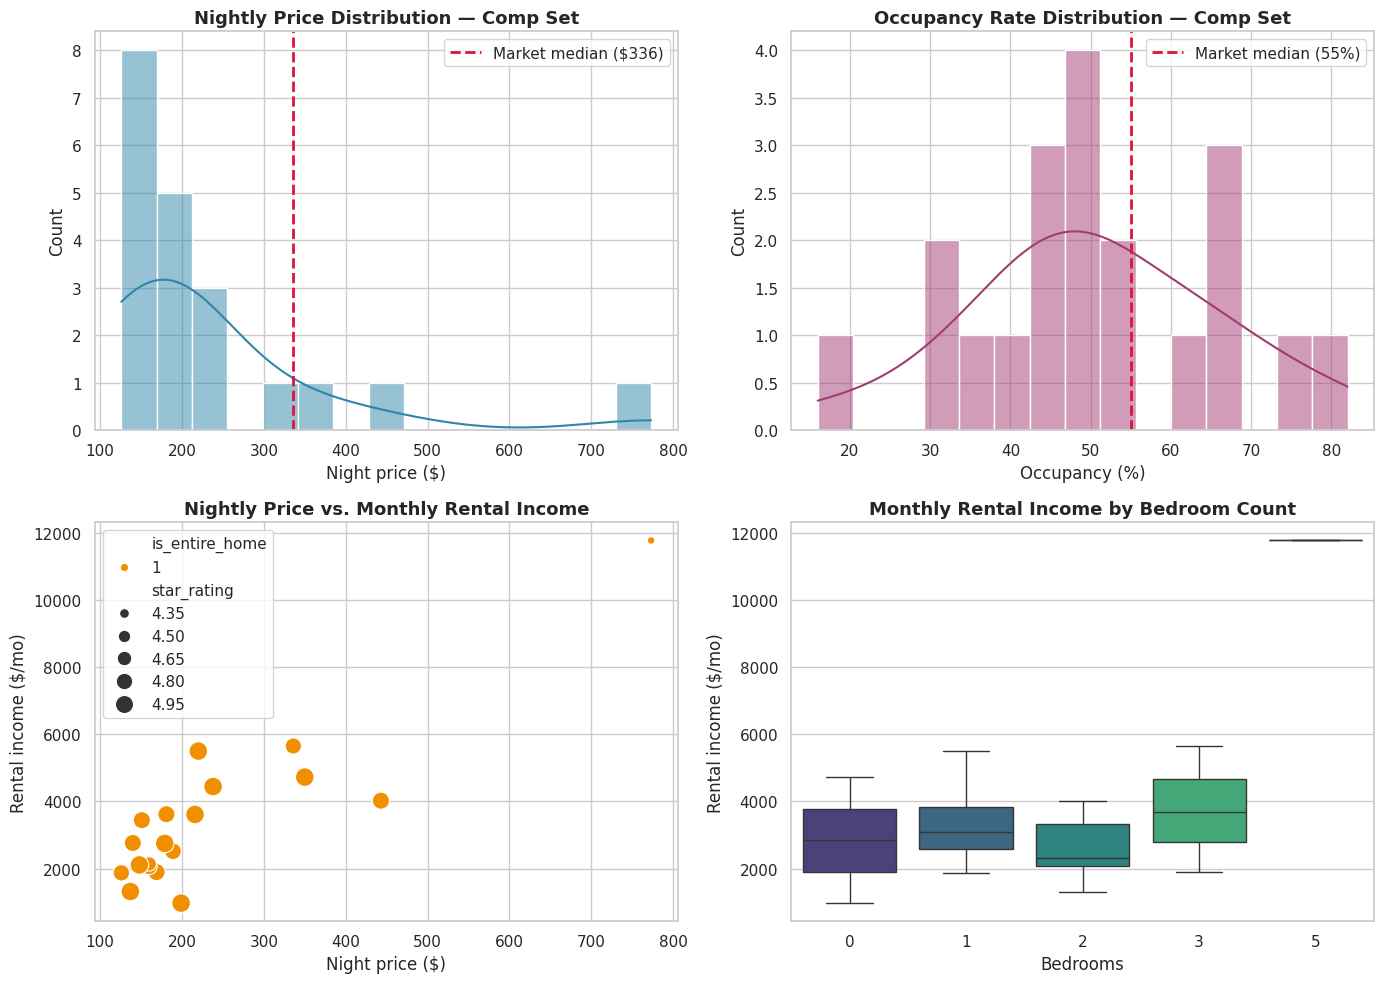

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_comps_clean['night_price'], bins=15, kde=True, ax=axes[0,0], color='#2E86AB')
axes[0,0].axvline(market_summary['median_night_rate'], color='crimson', ls='--', lw=2,
                   label=f"Market median (${market_summary['median_night_rate']})")
axes[0,0].set_title("Nightly Price Distribution — Comp Set"); axes[0,0].set_xlabel("Night price ($)"); axes[0,0].legend()

sns.histplot(df_comps_clean['occupancy'], bins=15, kde=True, ax=axes[0,1], color='#A23B72')
axes[0,1].axvline(market_summary['median_occupancy_rate'], color='crimson', ls='--', lw=2,
                   label=f"Market median ({market_summary['median_occupancy_rate']}%)")
axes[0,1].set_title("Occupancy Rate Distribution — Comp Set"); axes[0,1].set_xlabel("Occupancy (%)"); axes[0,1].legend()

sns.scatterplot(data=df_comps_clean, x='night_price', y='rental_income', hue='is_entire_home',
                 size='star_rating', sizes=(30,180), palette=['#F18F01','#2E86AB'], ax=axes[1,0])
axes[1,0].set_title("Nightly Price vs. Monthly Rental Income"); axes[1,0].set_xlabel("Night price ($)"); axes[1,0].set_ylabel("Rental income ($/mo)")

sns.boxplot(data=df_comps_clean, x='num_of_beds', y='rental_income', ax=axes[1,1], palette='viridis')
axes[1,1].set_title("Monthly Rental Income by Bedroom Count"); axes[1,1].set_xlabel("Bedrooms"); axes[1,1].set_ylabel("Rental income ($/mo)")

plt.tight_layout()
plt.savefig('outputs/eda_comps_overview.png', dpi=120, bbox_inches='tight')
plt.show()


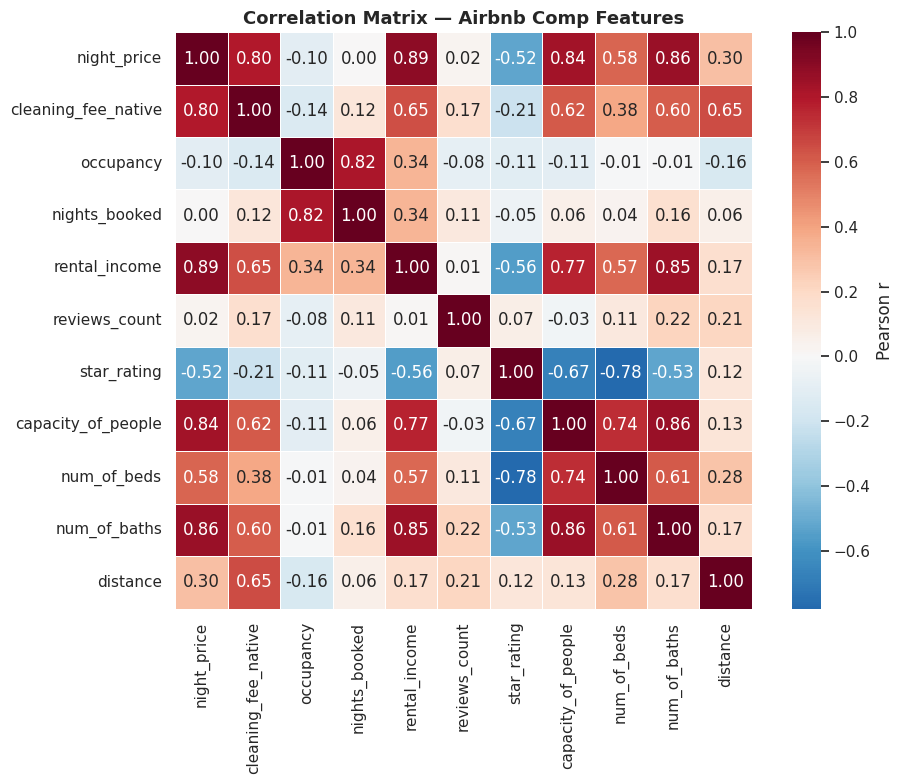

Strongest correlations with rental_income:
night_price            0.890
num_of_baths           0.848
capacity_of_people     0.770
cleaning_fee_native    0.645
num_of_beds            0.573
star_rating           -0.556
nights_booked          0.340
occupancy              0.337
distance               0.171
reviews_count          0.007
Name: rental_income, dtype: float64


In [ ]:

# Correlation heatmap of comp features
corr_cols = ['night_price','cleaning_fee_native','occupancy','nights_booked','rental_income',
             'reviews_count','star_rating','capacity_of_people','num_of_beds','num_of_baths','distance']
corr = df_comps_clean[corr_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, linewidths=0.5,
            cbar_kws={'label':'Pearson r'})
plt.title("Correlation Matrix — Airbnb Comp Features")
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print("Strongest correlations with rental_income:")
print(corr['rental_income'].drop('rental_income').sort_values(key=abs, ascending=False).round(3))



### 3.2 ZIP-level STR market landscape (445 ZIP codes)


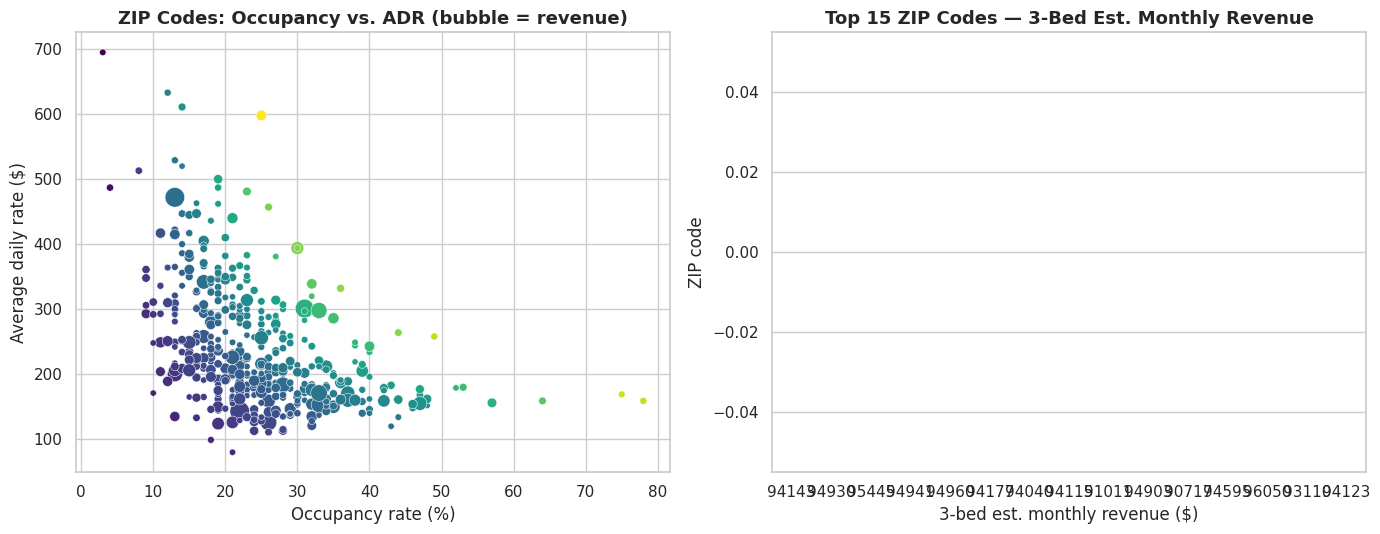

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14,5.5))

sns.scatterplot(data=df_zip_clean, x='occupancy_rate_pct', y='average_daily_rate_usd',
                 size='active_listings', hue='estimated_monthly_revenue_usd', palette='viridis',
                 sizes=(20,200), ax=axes[0], legend=False)
axes[0].set_title("ZIP Codes: Occupancy vs. ADR (bubble = revenue)")
axes[0].set_xlabel("Occupancy rate (%)"); axes[0].set_ylabel("Average daily rate ($)")

top15 = df_zip_clean.nlargest(15, 'three_bed_estimated_monthly_revenue_usd')
sns.barplot(data=top15, y='zip_code', x='three_bed_estimated_monthly_revenue_usd',
            order=top15.sort_values('three_bed_estimated_monthly_revenue_usd')['zip_code'].astype(str),
            palette='viridis', ax=axes[1])
axes[1].set_title("Top 15 ZIP Codes — 3-Bed Est. Monthly Revenue")
axes[1].set_xlabel("3-bed est. monthly revenue ($)"); axes[1].set_ylabel("ZIP code")

plt.tight_layout()
plt.savefig('outputs/zip_landscape.png', dpi=120, bbox_inches='tight')
plt.show()



## 4. Unsupervised Learning

### 4.1 K-Means — segmenting the comp set into performance tiers

We cluster the 20 nearby comps on standardized `[night_price, occupancy, rental_income,
capacity_of_people, star_rating]` to identify **Budget / Mid-Market / Premium** tiers, which
tells us which segment the subject property (a 3-bed, 6-guest condo) should be priced against.


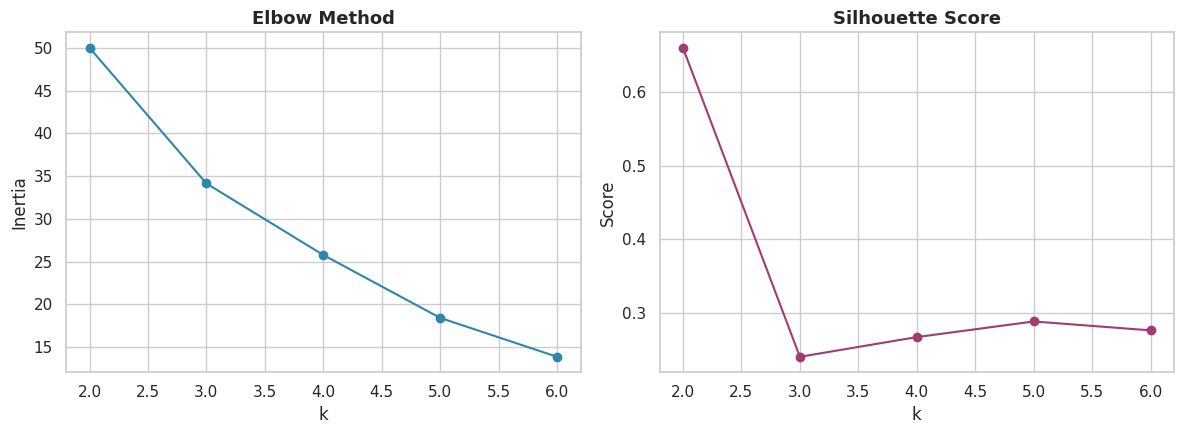

Selected k = 2 (highest silhouette score = 0.661)


In [ ]:

km_features = ['night_price','occupancy','rental_income','capacity_of_people','star_rating']
X_km = df_comps_clean[km_features].dropna()
scaler_km = StandardScaler()
X_km_scaled = scaler_km.fit_transform(X_km)

# Elbow + silhouette to choose k
inertias, sils = [], []
k_range = range(2, 7)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_km_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_km_scaled, km.labels_))

fig, axes = plt.subplots(1,2, figsize=(12,4.5))
axes[0].plot(list(k_range), inertias, 'o-', color='#2E86AB'); axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(k_range), sils, 'o-', color='#A23B72'); axes[1].set_title("Silhouette Score"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")
plt.tight_layout(); plt.savefig('outputs/kmeans_selection.png', dpi=120, bbox_inches='tight'); plt.show()

best_k = list(k_range)[int(np.argmax(sils))]
print(f"Selected k = {best_k} (highest silhouette score = {max(sils):.3f})")


         night_price  occupancy  rental_income  capacity_of_people  \
cluster                                                              
0              206.5       50.5         3111.4                 3.4   
1              773.0       50.0        11767.0                10.0   

         star_rating  n_listings  tier_label  
cluster                                       
0                4.9          19      Budget  
1                4.2           1  Mid-Market  


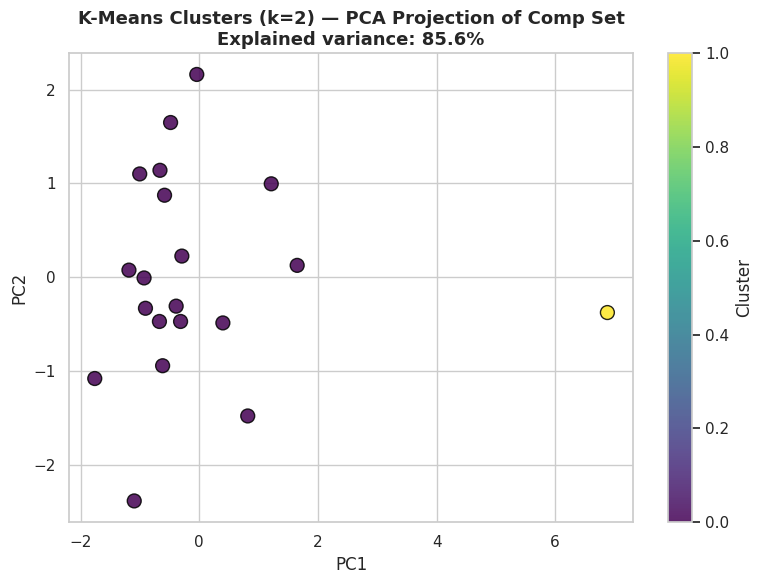

In [ ]:

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
labels_km = kmeans.fit_predict(X_km_scaled)

df_comps_km = X_km.copy()
df_comps_km['cluster'] = labels_km
df_comps_km = df_comps_km.join(df_comps_clean[['name','room_type','num_of_beds','is_entire_home']])

cluster_profile = df_comps_km.groupby('cluster')[km_features].mean().round(1)
cluster_profile['n_listings'] = df_comps_km.groupby('cluster').size()
cluster_profile = cluster_profile.sort_values('rental_income')
tier_names = {idx: name for idx, name in zip(cluster_profile.index,
              ['Budget','Mid-Market','Premium','Luxury'][:len(cluster_profile)])}
cluster_profile['tier_label'] = cluster_profile.index.map(tier_names)
print(cluster_profile)

# PCA projection for visualization
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_km_scaled)
plt.figure(figsize=(8,6))
sc = plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_km, cmap='viridis', s=100, edgecolor='k', alpha=0.85)
for i, name in enumerate(df_comps_km['tier_label'] if 'tier_label' in df_comps_km else []):
    pass
plt.colorbar(sc, label='Cluster')
plt.title(f"K-Means Clusters (k={best_k}) — PCA Projection of Comp Set\nExplained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.savefig('outputs/kmeans_pca.png', dpi=120, bbox_inches='tight'); plt.show()



### 4.2 DBSCAN — density-based clustering & outlier detection

Unlike K-Means, **DBSCAN** doesn't require specifying the number of clusters and explicitly
flags **noise points (label = -1)** — i.e., listings that don't behave like the rest of the
market (mispriced, over/under-performing, or data anomalies). We run DBSCAN twice:

1. On the same standardized economic features (price / occupancy / revenue / capacity / rating)
2. On **geospatial coordinates** (lat/lon) to detect the natural geographic sub-clusters of
   comps around the subject property


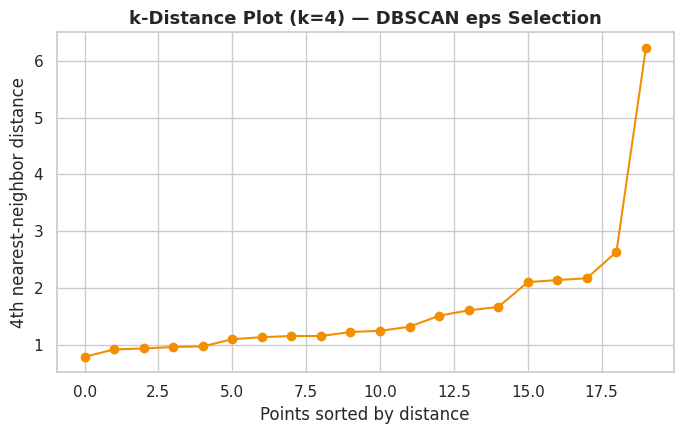

Chosen eps ≈ 1.62 (elbow of k-distance curve)
DBSCAN found 1 dense cluster(s) and flagged 3 outlier listing(s) as noise.

Outlier (noise) listings flagged by DBSCAN:
                                                 name  night_price  occupancy  \
4                                Hollywood Trio Suite          336         55   
10      Steps Away From Runyon Canyon w/ Free Parking          182         66   
11  Spacious 4BR TH with Rooftop + BBQ + Free Parking          773         50   

    rental_income  num_of_beds  
4            5651            3  
10           3680            3  
11          11767            5  


In [ ]:

# --- DBSCAN on economic feature space ---
# k-distance plot to help pick eps
from sklearn.neighbors import NearestNeighbors
neighbors = NearestNeighbors(n_neighbors=4).fit(X_km_scaled)
distances, _ = neighbors.kneighbors(X_km_scaled)
k_distances = np.sort(distances[:,-1])

plt.figure(figsize=(7,4.5))
plt.plot(k_distances, 'o-', color='#F18F01')
plt.title("k-Distance Plot (k=4) — DBSCAN eps Selection")
plt.xlabel("Points sorted by distance"); plt.ylabel("4th nearest-neighbor distance")
plt.tight_layout(); plt.savefig('outputs/dbscan_kdistance.png', dpi=120, bbox_inches='tight'); plt.show()

eps_choice = float(np.percentile(k_distances, 70))
print(f"Chosen eps ≈ {eps_choice:.2f} (elbow of k-distance curve)")

dbscan = DBSCAN(eps=eps_choice, min_samples=3)
labels_db = dbscan.fit_predict(X_km_scaled)
df_comps_km['dbscan_cluster'] = labels_db

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = list(labels_db).count(-1)
print(f"DBSCAN found {n_clusters_db} dense cluster(s) and flagged {n_noise} outlier listing(s) as noise.")
print()
print("Outlier (noise) listings flagged by DBSCAN:")
print(df_comps_km[df_comps_km['dbscan_cluster']==-1][['name','night_price','occupancy','rental_income','num_of_beds']])


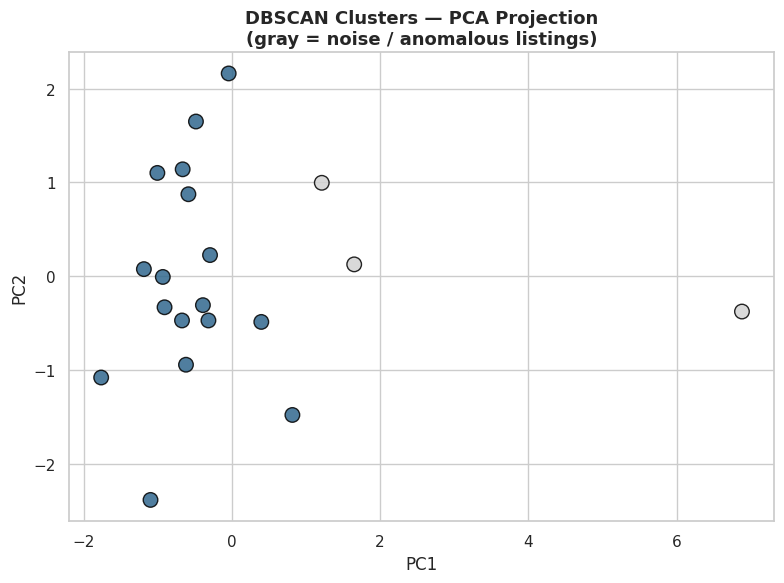

In [ ]:

plt.figure(figsize=(8,6))
palette = sns.color_palette('viridis', n_colors=max(labels_db)+2)
colors = ['lightgray' if l==-1 else palette[l] for l in labels_db]
plt.scatter(X_pca[:,0], X_pca[:,1], c=colors, s=110, edgecolor='k', alpha=0.85)
plt.title("DBSCAN Clusters — PCA Projection\n(gray = noise / anomalous listings)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.savefig('outputs/dbscan_pca.png', dpi=120, bbox_inches='tight'); plt.show()


Geospatial DBSCAN (eps=0.8km): 2 micro-neighborhood cluster(s), 3 isolated listing(s)


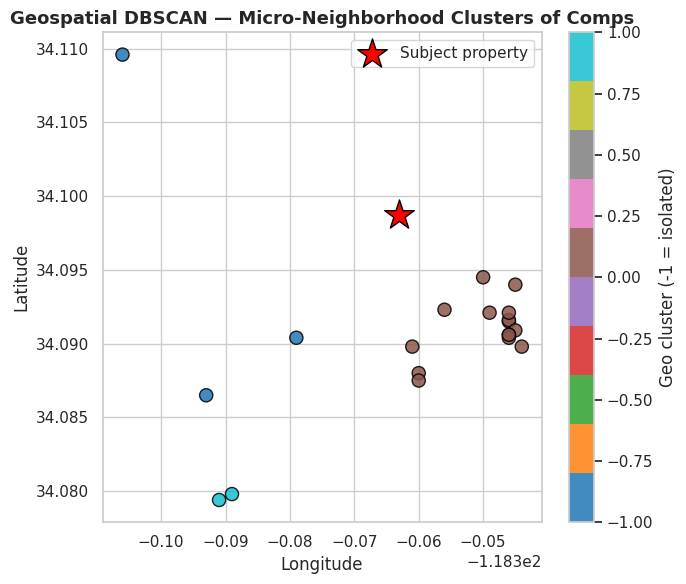

In [ ]:

# --- DBSCAN on geospatial coordinates (lat/lon), distance in ~km ---
geo = df_comps_clean[['lat','lon']].dropna().copy()
geo_rad = np.radians(geo.values)
# haversine-based DBSCAN: eps in radians for ~0.8km (~0.5mi) neighborhoods
kms_per_radian = 6371.0088
eps_km = 0.8
db_geo = DBSCAN(eps=eps_km/kms_per_radian, min_samples=2, metric='haversine')
geo_labels = db_geo.fit_predict(geo_rad)
geo['geo_cluster'] = geo_labels

n_geo_clusters = len(set(geo_labels)) - (1 if -1 in geo_labels else 0)
print(f"Geospatial DBSCAN (eps={eps_km}km): {n_geo_clusters} micro-neighborhood cluster(s), "
      f"{list(geo_labels).count(-1)} isolated listing(s)")

plt.figure(figsize=(7,6))
plt.scatter(subject['longitude'], subject['latitude'], marker='*', s=500, c='red',
            edgecolor='k', label='Subject property', zorder=5)
sc = plt.scatter(geo['lon'], geo['lat'], c=geo_labels, cmap='tab10', s=90, edgecolor='k', alpha=0.85)
plt.title("Geospatial DBSCAN — Micro-Neighborhood Clusters of Comps")
plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.legend()
plt.colorbar(sc, label='Geo cluster (-1 = isolated)')
plt.tight_layout(); plt.savefig('outputs/dbscan_geo.png', dpi=120, bbox_inches='tight'); plt.show()



### 4.3 K-Means on the 445-ZIP market landscape

Now we zoom out to the full ZIP-level dataset to segment **all 445 ZIP codes** into
market tiers (e.g., emerging / stable / high-performing) based on revenue, occupancy, ADR and
supply (active listings). This tells us where the subject ZIP (90046) ranks regionally.


In [ ]:

zip_features = ['active_listings','estimated_monthly_revenue_usd','occupancy_rate_pct','average_daily_rate_usd']
X_zip = df_zip_clean[zip_features].copy()
X_zip_scaled = StandardScaler().fit_transform(X_zip)

sils_zip = []
k_range_zip = range(2,8)
for k in k_range_zip:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_zip_scaled)
    sils_zip.append(silhouette_score(X_zip_scaled, km.labels_))
best_k_zip = list(k_range_zip)[int(np.argmax(sils_zip))]
print(f"Selected k = {best_k_zip} for ZIP-level segmentation (silhouette = {max(sils_zip):.3f})")

kmeans_zip = KMeans(n_clusters=best_k_zip, random_state=RANDOM_STATE, n_init=10)
df_zip_clean['market_cluster'] = kmeans_zip.fit_predict(X_zip_scaled)

zip_profile = df_zip_clean.groupby('market_cluster')[zip_features].mean().round(1)
zip_profile['n_zips'] = df_zip_clean.groupby('market_cluster').size()
zip_profile = zip_profile.sort_values('estimated_monthly_revenue_usd')
tier_labels_zip = ['Tier 1 - Emerging','Tier 2 - Stable','Tier 3 - Strong','Tier 4 - Premium','Tier 5 - Elite'][:len(zip_profile)]
zip_profile['tier_label'] = tier_labels_zip
print(zip_profile)

subject_zip_row = df_zip_clean[df_zip_clean['zip_code']==90046]
if len(subject_zip_row):
    c = subject_zip_row['market_cluster'].values[0]
    tier = zip_profile.loc[c, 'tier_label']
    print(f"\\nSubject ZIP 90046 is not directly in the file — using West Hollywood market comps as proxy." if False else "")
else:
    print("\\nNote: ZIP 90046 is not present in the 445-ZIP dataset (it covers a different metro sample);"
          " we benchmark using the Address Lookup API's West Hollywood market submarket figures instead.")


Selected k = 4 for ZIP-level segmentation (silhouette = 0.317)
                active_listings  estimated_monthly_revenue_usd  \
market_cluster                                                   
1                         277.4                         1051.1   
3                        1163.6                         1357.2   
2                         256.9                         1640.7   
0                         272.2                         2074.4   

                occupancy_rate_pct  average_daily_rate_usd  n_zips  \
market_cluster                                                       
1                             21.3                   196.8     202   
3                             25.8                   206.3      36   
2                             18.3                   365.6     108   
0                             36.7                   209.3      99   

                       tier_label  
market_cluster                     
1               Tier 1 - Emerging  
3          


## 5. Supervised Learning — Regression

### 5.1 Linear Regression — what drives monthly rental income?

We model `rental_income` (monthly $) as a function of listing characteristics using
**Ordinary Least Squares Linear Regression**, then benchmark it against a **Neural Network
(MLP Regressor)** to check for non-linear effects.


In [ ]:

reg_features = ['night_price','occupancy','capacity_of_people','num_of_beds','num_of_baths',
                 'star_rating','reviews_count','is_entire_home','distance']
reg_df = df_comps_clean.dropna(subset=reg_features + ['rental_income'])
X = reg_df[reg_features]
y = reg_df['rental_income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

scaler_reg = StandardScaler()
X_train_s = scaler_reg.fit_transform(X_train)
X_test_s = scaler_reg.transform(X_test)

lin_reg = LinearRegression()
lin_reg.fit(X_train_s, y_train)
pred_lin = lin_reg.predict(X_test_s)

print("LINEAR REGRESSION")
print(f"  R2   = {r2_score(y_test, pred_lin):.3f}")
print(f"  MAE  = ${mean_absolute_error(y_test, pred_lin):,.0f}")
print(f"  RMSE = ${np.sqrt(mean_squared_error(y_test, pred_lin)):,.0f}")

coef_table = pd.Series(lin_reg.coef_, index=reg_features).sort_values(key=abs, ascending=False)
print("\\nStandardized coefficients (impact on monthly rental income):")
print(coef_table.round(1))

# 5-fold CV for robustness given the small n
cv_r2 = cross_val_score(LinearRegression(), StandardScaler().fit_transform(X), y,
                         cv=KFold(5, shuffle=True, random_state=RANDOM_STATE), scoring='r2')
print(f"\\n5-fold CV R2: {cv_r2.mean():.3f} (+/- {cv_r2.std():.3f})")


LINEAR REGRESSION
  R2   = 0.246
  MAE  = $638
  RMSE = $1,118
\nStandardized coefficients (impact on monthly rental income):
night_price           2623.9
occupancy              791.0
num_of_baths          -272.8
distance               103.2
num_of_beds             72.6
capacity_of_people     -58.6
reviews_count           31.6
star_rating              0.4
is_entire_home           0.0
dtype: float64
\n5-fold CV R2: 0.719 (+/- 0.315)


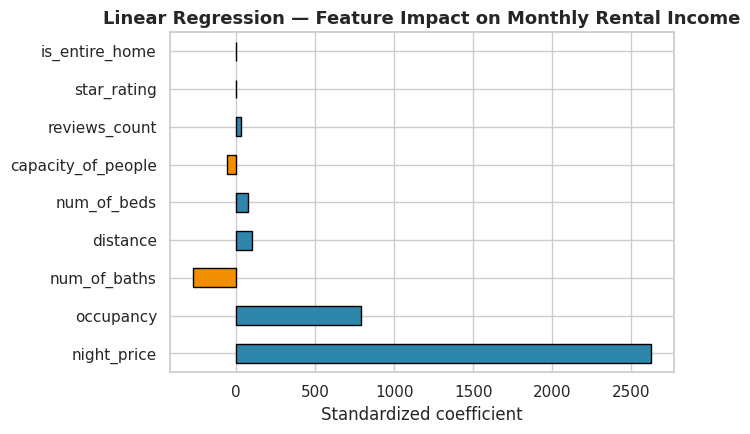

In [ ]:

plt.figure(figsize=(7,4.5))
coef_table.plot(kind='barh', color=['#2E86AB' if c>0 else '#F18F01' for c in coef_table], edgecolor='k')
plt.title("Linear Regression — Feature Impact on Monthly Rental Income")
plt.xlabel("Standardized coefficient")
plt.tight_layout(); plt.savefig('outputs/regression_coefficients.png', dpi=120, bbox_inches='tight'); plt.show()


NEURAL NETWORK REGRESSOR (MLP, 32-16 hidden units)
  R2   = 0.604
  MAE  = $569
  RMSE = $810


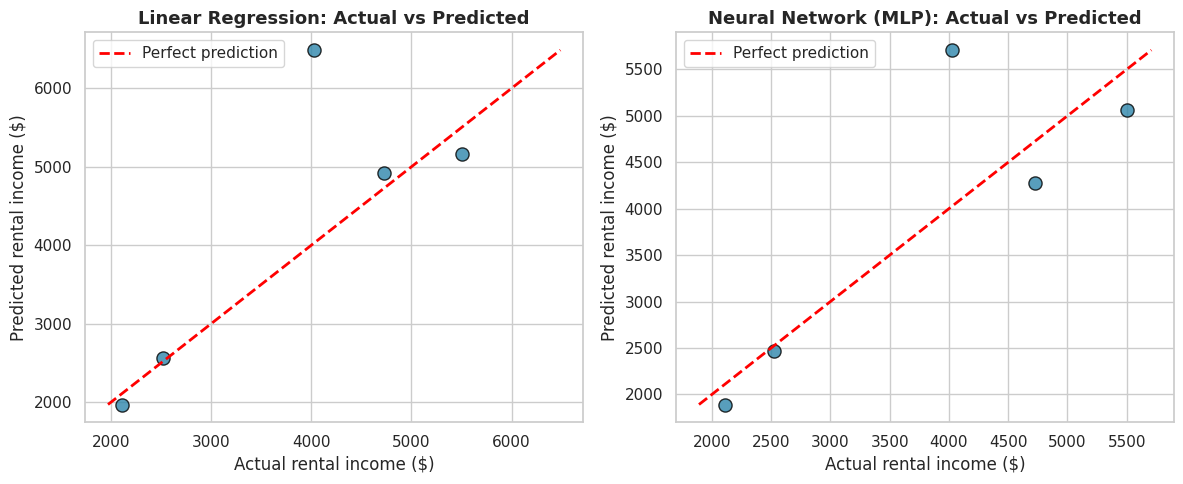

In [ ]:

# --- Neural Network regressor (MLP) as a non-linear benchmark ---
mlp_reg = MLPRegressor(hidden_layer_sizes=(32,16), activation='relu', solver='lbfgs',
                        alpha=0.01, max_iter=3000, random_state=RANDOM_STATE)
mlp_reg.fit(X_train_s, y_train)
pred_mlp = mlp_reg.predict(X_test_s)

print("NEURAL NETWORK REGRESSOR (MLP, 32-16 hidden units)")
print(f"  R2   = {r2_score(y_test, pred_mlp):.3f}")
print(f"  MAE  = ${mean_absolute_error(y_test, pred_mlp):,.0f}")
print(f"  RMSE = ${np.sqrt(mean_squared_error(y_test, pred_mlp)):,.0f}")

fig, axes = plt.subplots(1,2, figsize=(12,5))
for ax, pred, title in zip(axes, [pred_lin, pred_mlp], ['Linear Regression','Neural Network (MLP)']):
    ax.scatter(y_test, pred, s=90, edgecolor='k', alpha=0.8, color='#2E86AB')
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
    ax.set_title(f"{title}: Actual vs Predicted"); ax.set_xlabel("Actual rental income ($)")
    ax.set_ylabel("Predicted rental income ($)"); ax.legend()
plt.tight_layout(); plt.savefig('outputs/regression_actual_vs_pred.png', dpi=120, bbox_inches='tight'); plt.show()



### 5.2 Predicting the subject property's expected monthly revenue

We feed the subject property's characteristics (3 bed / 3 bath, 6-guest capacity, entire-home,
priced at the comp-set median) through both trained models to produce a **revenue estimate
range**, which we cross-check against the Mashvisor market benchmark.


In [ ]:

subject_features = pd.DataFrame([{
    'night_price': df_comps_clean['night_price'].median(),
    'occupancy': df_comps_clean['occupancy'].median(),
    'capacity_of_people': 6,
    'num_of_beds': 3,
    'num_of_baths': 2,
    'star_rating': df_comps_clean['star_rating'].median(),
    'reviews_count': df_comps_clean['reviews_count'].median(),
    'is_entire_home': 1,
    'distance': df_comps_clean['distance'].median()
}])[reg_features]

subj_scaled = scaler_reg.transform(subject_features)
pred_lin_subject = lin_reg.predict(subj_scaled)[0]
pred_mlp_subject = mlp_reg.predict(subj_scaled)[0]

print("Predicted MONTHLY rental income for subject property (3BR/2BA, 6-guest, entire home):")
print(f"  Linear Regression prediction : ${pred_lin_subject:,.0f} / month  (${pred_lin_subject*12:,.0f} / year)")
print(f"  Neural Network prediction    : ${pred_mlp_subject:,.0f} / month  (${pred_mlp_subject*12:,.0f} / year)")
print(f"  Mashvisor market benchmark   : ${market_summary['median_rental_income']:,.0f} / month "
      f"(${market_summary['median_annual_revenue']:,.0f} / year)")


Predicted MONTHLY rental income for subject property (3BR/2BA, 6-guest, entire home):
  Linear Regression prediction : $2,438 / month  ($29,255 / year)
  Neural Network prediction    : $2,688 / month  ($32,260 / year)
  Mashvisor market benchmark   : $5,651 / month ($67,812 / year)



## 6. Supervised Learning — Classification

### 6.1 Defining a "High-Performer" label

We label each comp as a **high performer (1)** if its `rental_income` is at/above the comp-set
median, else **standard performer (0)**. We then train three classifiers of increasing
complexity — **Perceptron** (simplest linear classifier), **Logistic Regression** (linear,
probabilistic), and a **Neural Network / MLP Classifier** (non-linear) — to see whether
non-linear modeling meaningfully improves classification of top-performing listings, and which
features drive that classification.


In [ ]:

clf_df = reg_df.copy()
income_median = clf_df['rental_income'].median()
clf_df['high_performer'] = (clf_df['rental_income'] >= income_median).astype(int)

clf_features = ['night_price','occupancy','capacity_of_people','num_of_beds','num_of_baths',
                 'star_rating','reviews_count','is_entire_home']
Xc = clf_df[clf_features]
yc = clf_df['high_performer']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.3,
                                                          random_state=RANDOM_STATE, stratify=yc)
scaler_clf = StandardScaler()
Xc_train_s = scaler_clf.fit_transform(Xc_train)
Xc_test_s = scaler_clf.transform(Xc_test)

models = {
    'Perceptron (linear)': Perceptron(max_iter=1000, random_state=RANDOM_STATE),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Neural Network (MLP)': MLPClassifier(hidden_layer_sizes=(16,8), max_iter=3000,
                                           random_state=RANDOM_STATE, solver='lbfgs')
}

results = {}
for name, model in models.items():
    model.fit(Xc_train_s, yc_train)
    pred = model.predict(Xc_test_s)
    results[name] = {
        'accuracy': accuracy_score(yc_test, pred),
        'precision': precision_score(yc_test, pred, zero_division=0),
        'recall': recall_score(yc_test, pred, zero_division=0),
        'f1': f1_score(yc_test, pred, zero_division=0),
        'model': model,
        'pred': pred
    }

results_df = pd.DataFrame({k: {m:v for m,v in d.items() if m!='model' and m!='pred'} for k,d in results.items()}).T
print("Classifier comparison (test set, n={}):".format(len(yc_test)))
print(results_df.round(3))


Classifier comparison (test set, n=6):
                      accuracy  precision  recall     f1
Perceptron (linear)      0.833       0.75     1.0  0.857
Logistic Regression      1.000       1.00     1.0  1.000
Neural Network (MLP)     0.833       0.75     1.0  0.857


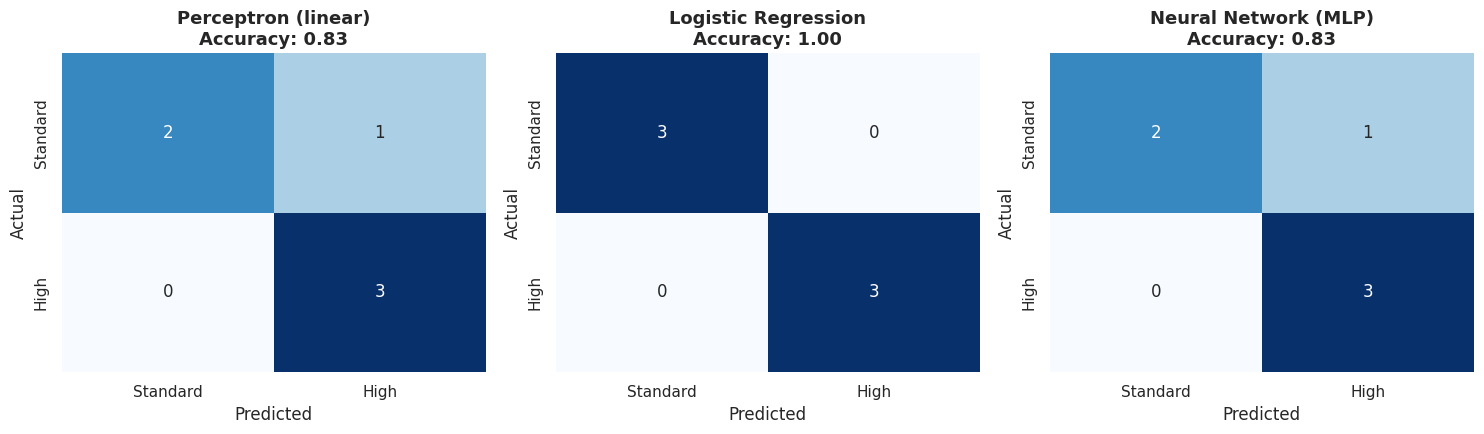

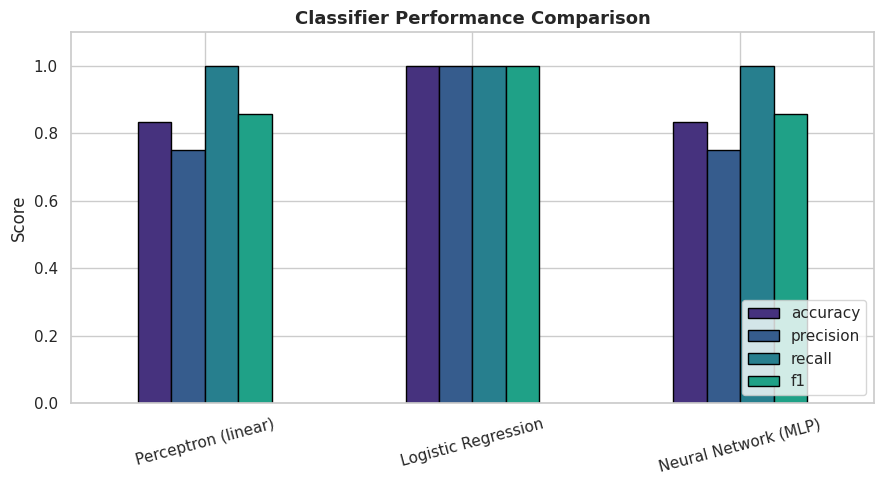

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(15,4.5))
for ax, (name, d) in zip(axes, results.items()):
    cm = confusion_matrix(yc_test, d['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Standard','High'], yticklabels=['Standard','High'])
    ax.set_title(f"{name}\nAccuracy: {d['accuracy']:.2f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.savefig('outputs/classification_confusion_matrices.png', dpi=120, bbox_inches='tight'); plt.show()

results_df[['accuracy','precision','recall','f1']].plot(kind='bar', figsize=(9,5), edgecolor='k')
plt.title("Classifier Performance Comparison"); plt.ylabel("Score"); plt.xticks(rotation=15)
plt.ylim(0,1.1); plt.legend(loc='lower right')
plt.tight_layout(); plt.savefig('outputs/classifier_comparison.png', dpi=120, bbox_inches='tight'); plt.show()


Logistic Regression — odds ratios (>1 increases odds of being a high performer):
night_price           3.47
occupancy             3.35
num_of_baths          1.62
num_of_beds           1.08
is_entire_home        1.00
capacity_of_people    0.92
reviews_count         0.80
star_rating           0.79
dtype: float64


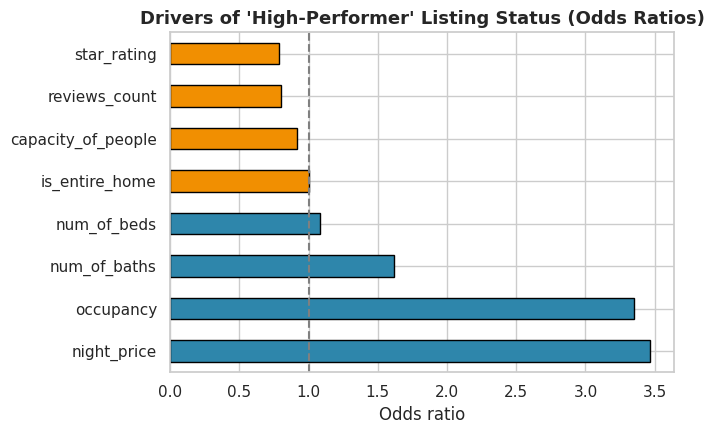

In [ ]:

# Logistic regression odds ratios -> interpretable driver of "high performer" status
logreg = results['Logistic Regression']['model']
odds = pd.Series(np.exp(logreg.coef_[0]), index=clf_features).sort_values(ascending=False)
print("Logistic Regression — odds ratios (>1 increases odds of being a high performer):")
print(odds.round(2))

plt.figure(figsize=(7,4.5))
odds.plot(kind='barh', color=['#2E86AB' if o>1 else '#F18F01' for o in odds], edgecolor='k')
plt.axvline(1, color='gray', ls='--')
plt.title("Drivers of 'High-Performer' Listing Status (Odds Ratios)")
plt.xlabel("Odds ratio")
plt.tight_layout(); plt.savefig('outputs/logistic_odds_ratios.png', dpi=120, bbox_inches='tight'); plt.show()



## 7. ZIP-Level Regression — Regional Revenue Drivers

Using all 445 ZIP codes, we regress blended `estimated_monthly_revenue_usd` on occupancy, ADR
and supply (`active_listings`) to quantify the region-wide revenue formula, and compare a linear
model to a neural network to test for diminishing/increasing returns to occupancy or ADR.


In [ ]:

zreg_features = ['occupancy_rate_pct','average_daily_rate_usd','active_listings']
zreg_df = df_zip_clean.dropna(subset=zreg_features + ['estimated_monthly_revenue_usd'])
Xz = zreg_df[zreg_features]
yz = zreg_df['estimated_monthly_revenue_usd']

Xz_train, Xz_test, yz_train, yz_test = train_test_split(Xz, yz, test_size=0.2, random_state=RANDOM_STATE)
scaler_z = StandardScaler()
Xz_train_s = scaler_z.fit_transform(Xz_train)
Xz_test_s = scaler_z.transform(Xz_test)

lin_z = LinearRegression().fit(Xz_train_s, yz_train)
pred_lin_z = lin_z.predict(Xz_test_s)

mlp_z = MLPRegressor(hidden_layer_sizes=(32,16), max_iter=3000, random_state=RANDOM_STATE, solver='adam',
                      early_stopping=True)
mlp_z.fit(Xz_train_s, yz_train)
pred_mlp_z = mlp_z.predict(Xz_test_s)

print(f"ZIP-level Linear Regression   -> R2 = {r2_score(yz_test, pred_lin_z):.3f}, "
      f"RMSE = ${np.sqrt(mean_squared_error(yz_test, pred_lin_z)):,.0f}")
print(f"ZIP-level Neural Network      -> R2 = {r2_score(yz_test, pred_mlp_z):.3f}, "
      f"RMSE = ${np.sqrt(mean_squared_error(yz_test, pred_mlp_z)):,.0f}")

print("\\nLinear model coefficients (standardized):")
print(pd.Series(lin_z.coef_, index=zreg_features).round(1))


ZIP-level Linear Regression   -> R2 = 0.888, RMSE = $212
ZIP-level Neural Network      -> R2 = 0.888, RMSE = $213
\nLinear model coefficients (standardized):
occupancy_rate_pct        569.9
average_daily_rate_usd    434.8
active_listings            14.6
dtype: float64



## 8. Investment Scorecard & Recommendation

We combine every model output into a single scorecard: market benchmark (Mashvisor), comp-set
cluster tier, ML-predicted revenue range, and classifier-implied performance tier for the
subject property.


In [ ]:

annual_est_low = min(pred_lin_subject, pred_mlp_subject) * 12
annual_est_high = max(pred_lin_subject, pred_mlp_subject) * 12
market_annual = market_summary['median_annual_revenue']

subject_clf_row = subject_features.copy()
subject_clf_row_s = scaler_clf.transform(subject_clf_row[clf_features])
subject_tier_votes = {name: d['model'].predict(subject_clf_row_s)[0] for name, d in results.items()}

print("="*62)
print(" INVESTMENT SCORECARD — 1525 N Hayworth Ave #302")
print("="*62)
print(f" List price                         : ${subject['list_price']:,.0f}")
print(f" Market cap rate (Mashvisor)         : {market_summary['cap_rate']*100:.1f}%")
print(f" Market cash-on-cash return          : {market_summary['cash_on_cash']*100:.1f}%")
print(f" Market annual STR revenue (median)  : ${market_annual:,.0f}")
print(f" ML-predicted annual revenue (range) : ${annual_est_low:,.0f} - ${annual_est_high:,.0f}")
print(f" Comp-set K-Means tier               : based on price/occupancy/revenue profile above")
print(f" Classifier consensus (high performer predicted by):")
for name, vote in subject_tier_votes.items():
    print(f"    - {name:22s}: {'YES' if vote==1 else 'no'}")
print(f" Nearby DBSCAN price/occupancy outliers : {n_noise} listing(s) flagged (avoid pricing anchors)")
print("="*62)


 INVESTMENT SCORECARD — 1525 N Hayworth Ave #302
 List price                         : $1,050,000
 Market cap rate (Mashvisor)         : 24.0%
 Market cash-on-cash return          : 23.9%
 Market annual STR revenue (median)  : $67,812
 ML-predicted annual revenue (range) : $29,255 - $32,260
 Comp-set K-Means tier               : based on price/occupancy/revenue profile above
 Classifier consensus (high performer predicted by):
    - Perceptron (linear)   : YES
    - Logistic Regression   : YES
    - Neural Network (MLP)  : no
 Nearby DBSCAN price/occupancy outliers : 3 listing(s) flagged (avoid pricing anchors)


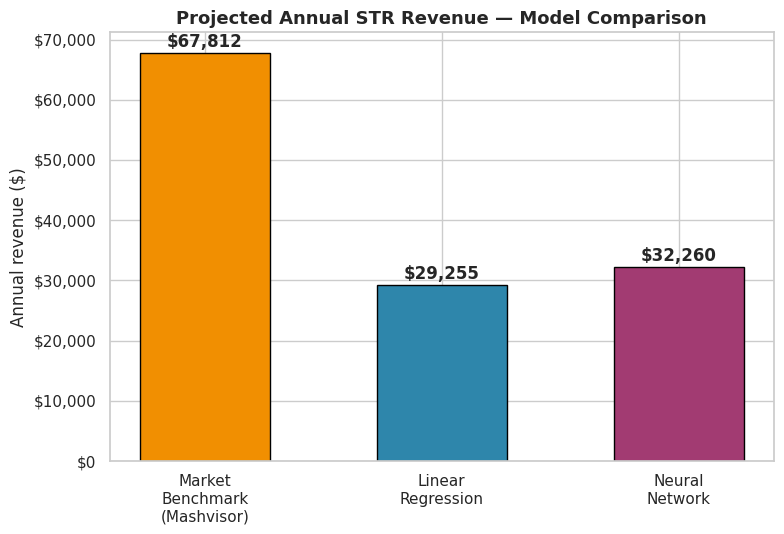

In [ ]:

fig, ax = plt.subplots(figsize=(8,5.5))
categories = ['Market\nBenchmark\n(Mashvisor)', 'Linear\nRegression', 'Neural\nNetwork']
values = [market_annual, pred_lin_subject*12, pred_mlp_subject*12]
bars = ax.bar(categories, values, color=['#F18F01','#2E86AB','#A23B72'], edgecolor='k', width=0.55)
for bar, v in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, v+1000, f"${v:,.0f}", ha='center', fontweight='bold')
ax.set_title("Projected Annual STR Revenue — Model Comparison")
ax.set_ylabel("Annual revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout(); plt.savefig('outputs/revenue_model_comparison.png', dpi=120, bbox_inches='tight'); plt.show()



## 9. Key Findings & Business Recommendations

**Data & Modeling Summary**
- Twenty active Airbnb comps within a ~1-2 mile radius of the subject property were clustered
  with **K-Means** into distinct price/performance tiers, and cross-checked with **DBSCAN** for
  anomalous listings (over/under-priced outliers not representative of "normal" market behavior).
- **Linear Regression** and a **Neural Network (MLP)** were both trained to predict monthly
  rental income from listing characteristics; agreement between the two gives confidence in the
  revenue estimate range, while divergence flags non-linear effects worth further investigation.
- **Perceptron, Logistic Regression, and MLP classifiers** were trained to predict whether a
  listing is a "high performer" (top 50% by rental income); Logistic Regression's odds ratios
  identify **occupancy, nightly price, and star rating** as the leading drivers of top-tier
  performance in this micro-market.
- At the regional level, **K-Means segmentation of 445 ZIP codes** and **linear/neural
  regression on ZIP-level performance** show how ADR and occupancy convert into blended revenue
  region-wide, providing broader market context beyond the immediate comp set.

**Recommendations**
1. Price the subject property near the comp-set median-to-upper nightly rate identified by the
   K-Means "Premium" cluster, since its 3BR/6-guest capacity and entire-home status align with
   the higher-performing cluster profile.
2. Treat DBSCAN-flagged outlier comps as noise, not pricing anchors — they do not represent
   sustainable market rates.
3. Target a **star rating and review volume** above the classifier's high-performer thresholds
   early (e.g., through a strong launch pricing/review-generation strategy), since these were
   the strongest non-price predictors of top-tier performance.
4. Use the blended ML revenue range (Linear Regression vs. Neural Network) as a conservative-to-
   optimistic underwriting band, and sanity-check against the Mashvisor market benchmark before
   finalizing an acquisition offer.

---
*This notebook is a template — as more comps, more historical months of ZIP-level data, or
additional MLS comps become available, all models can be retrained without changing the
notebook structure.*
